# IND320 - Compulsory Work, Part 1

**Name:** Kittel Johannes Lande

**GitHub repository:** https://github.com/Kitteljl/IND320-app

**Streamlit app:** https://ind320-app-kittel.streamlit.app/

This notebook documents the first compulsory hand-in for IND320. It covers reading, cleaning,
inspecting and visualising the `reservoirs.csv` dataset, which will later be used as the data
source for the accompanying Streamlit app.


## 1. Imports

We use `pandas` for data handling and `matplotlib` for plotting. Both are listed in
`requirements.txt` in the GitHub repository so the environment is reproducible.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Make plots a bit larger and more readable by default
plt.rcParams["figure.figsize"] = (10, 4)



## 2. Reading the data

The dataset `reservoirs.csv` contains weekly Norwegian hydropower reservoir statistics
(magasinstatistikk), broken down by price area (`omrnr`). Each row represents one
price area in one ISO week of one ISO year.

We parse the date column directly as a datetime so it can be used on plot axes later.


In [2]:
# Read the CSV file, parsing the date column as datetime
df_raw = pd.read_csv("/Users/kittellande/Documents/Ind320 - Kitteljl/data/reservoirs.csv", parse_dates=["dato_Id"])

# Quick look at the raw, unprocessed data
df_raw.head()


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 3. Renaming columns

The original column names are a mix of Norwegian and abbreviations. We rename them to
clear, consistent, English names so the rest of the notebook (and the Streamlit app) is
easy to read and maintain for anyone who inherits this project.



In [3]:
column_rename_map = {
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "fill_level",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "fill_twh",
    "neste_Publiseringsdato": "next_publish_date",
    "fyllingsgrad_forrige_uke": "fill_level_prev_week",
    "endring_fyllingsgrad": "fill_level_change",
}

df = df_raw.rename(columns=column_rename_map)

# Changing "0001-01-01" with (NaT)
df["next_publish_date"] = pd.to_datetime(df["next_publish_date"], errors="coerce")
df.loc[df["next_publish_date"].dt.year == 1, "next_publish_date"] = pd.NaT

# The dataset covers several price areas across many years. For clear, single-line
# plots we focus on one price area (here: area 4) and sort chronologically.
# (Change AREA_OF_INTEREST below to explore a different area.)
AREA_OF_INTEREST = 4
df = (
    df[df["area_number"] == AREA_OF_INTEREST]
    .sort_values("date")
    .reset_index(drop=True)
)

df.head()


,date,area_type,area_number,iso_year,iso_week,fill_level,capacity_twh,fill_twh,next_publish_date,fill_level_prev_week,fill_level_change
0,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
1,1995-01-15,EL,4,1995,2,0.540690,21.079208,11.397317,0001-01-01T00:00:00,0.558864,-0.018174
2,1995-01-22,EL,4,1995,3,0.522262,21.079208,11.008863,0001-01-01T00:00:00,0.540690,-0.018428
3,1995-01-29,EL,4,1995,4,0.501427,21.079208,10.569689,0001-01-01T00:00:00,0.522262,-0.020835
4,1995-02-05,EL,4,1995,5,0.481138,21.079208,10.142017,0001-01-01T00:00:00,0.501427,-0.020289


## 4. Inspecting the data

Before plotting, we print a short overview of the cleaned dataset: its shape, the time
span it covers, column data types, and summary statistics for the numeric columns.


In [4]:
print(f"Number of rows: {len(df)}")
print(f"Price area: {AREA_OF_INTEREST}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print()
print("Column data types:")
print(df.dtypes)


Number of rows: 1653
Price area: 4
Date range: 1995-01-08 to 2026-09-06

Column data types:
date                    datetime64[us]
area_type                          str
area_number                      int64
iso_year                         int64
iso_week                         int64
fill_level                     float64
capacity_twh                   float64
fill_twh                       float64
next_publish_date                  str
fill_level_prev_week           float64
fill_level_change              float64
dtype: object


In [5]:
# Summary statistics for the numeric columns
df.describe()


,date,area_number,iso_year,iso_week,fill_level,capacity_twh,fill_twh,fill_level_prev_week,fill_level_change
count,1653,1653.0,1653.000000,1653.000000,1653.000000,1653.000000,1653.000000,1653.000000,1653.000000
mean,2010-11-07 00:00:00,4.0,2010.346038,26.405929,0.653022,21.079208,13.765182,0.652961,0.000061
min,1995-01-08 00:00:00,4.0,1995.000000,1.000000,0.206526,21.079208,4.353400,0.206526,-0.242484
25%,2002-12-08 00:00:00,4.0,2002.000000,13.000000,0.515226,21.079208,10.860564,0.515226,-0.017178
50%,2010-11-07 00:00:00,4.0,2010.000000,26.000000,0.669945,21.079208,14.121914,0.669945,-0.007412
75%,2018-10-07 00:00:00,4.0,2018.000000,39.000000,0.801864,21.079208,16.902666,0.801348,0.012844
max,2026-09-06 00:00:00,4.0,2026.000000,53.000000,0.979832,21.079208,20.654087,0.979832,0.114678
std,NaN,0.0,9.149156,15.021950,0.180347,0.000000,3.801579,0.180280,0.024150


## 5. Plotting each column separately

Each numeric column is plotted on its own axis against time. Plotting them separately
first lets us inspect the shape and scale of each variable individually before
combining them.


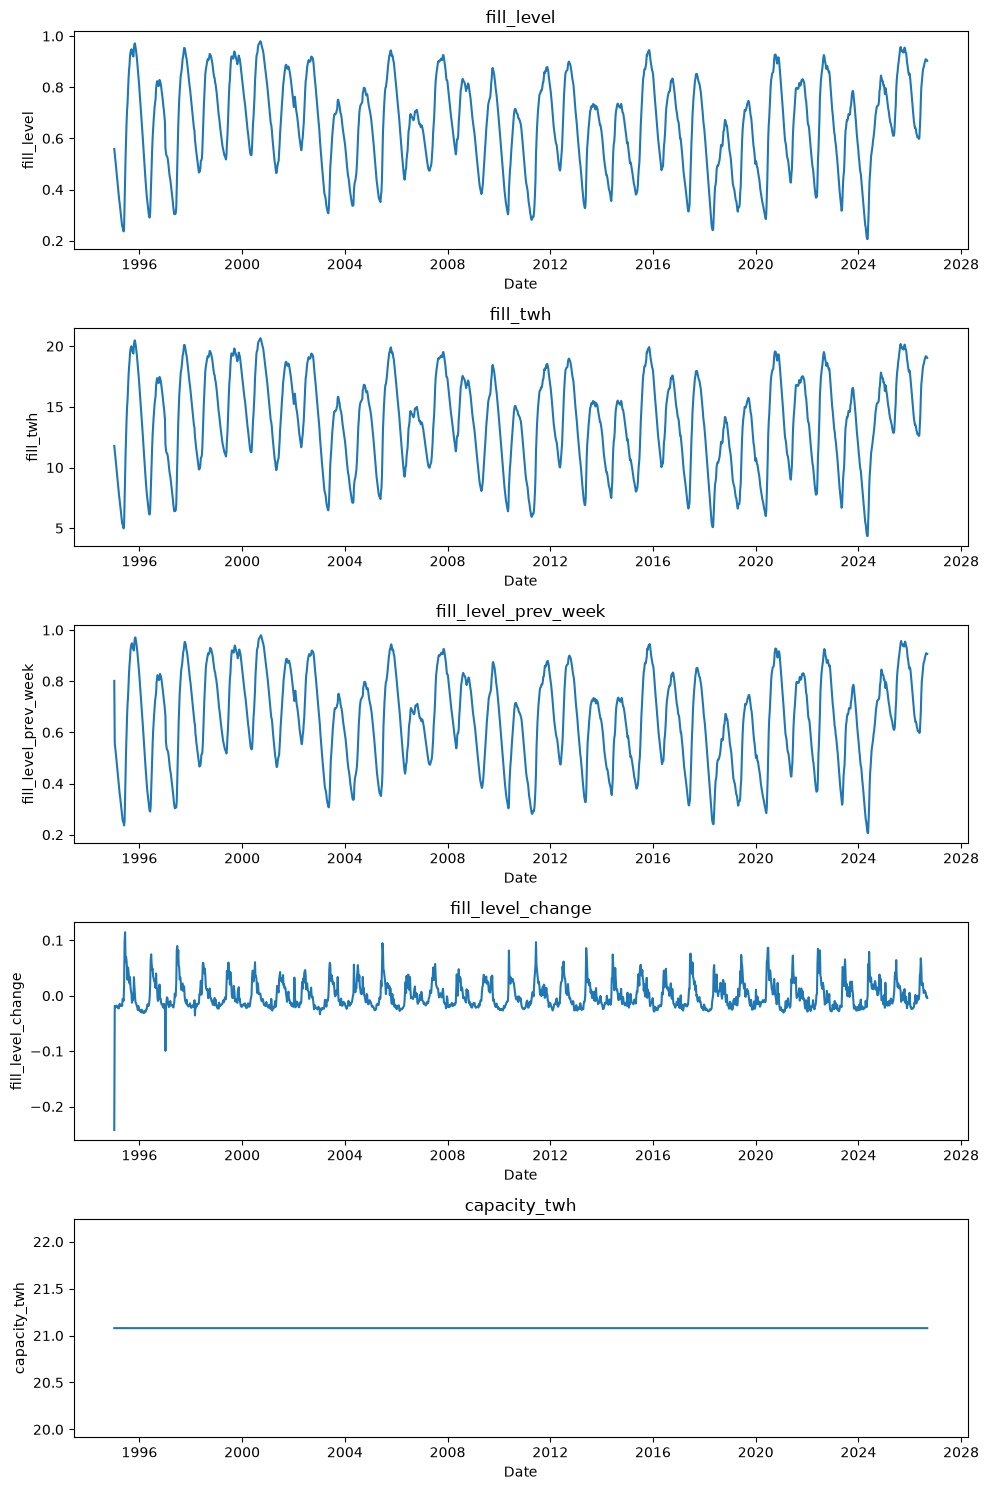

In [7]:
numeric_cols = [
    "fill_level",
    "fill_twh",
    "fill_level_prev_week",
    "fill_level_change",
    "capacity_twh"
]

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 3 * len(numeric_cols)))

for ax, col in zip(axes, numeric_cols):
    ax.plot(df["date"], df[col])
    ax.set_title(col)
    ax.set_xlabel("Date")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


## 6. Plotting all columns together

We group the columns by their **natural unit** and give each group its own
y-axis, instead of normalising all columns onto a single shared scale:

- **Left axis (fractions, roughly 0-1):** `fill_level`, `fill_level_prev_week`,
  and `fill_level_change`.
- **Right axis (TWh):** `capacity_twh` and `fill_twh`.

This keeps every column on a scale where its variation is clearly visible. A
dashed, semi-transparent line is used for `fill_level_prev_week` so it remains
visible as a faint "echo" behind `fill_level` rather than being hidden by it,
and a horizontal line at 0 is added to make it easy to see when
`fill_level_change` is positive or negative.

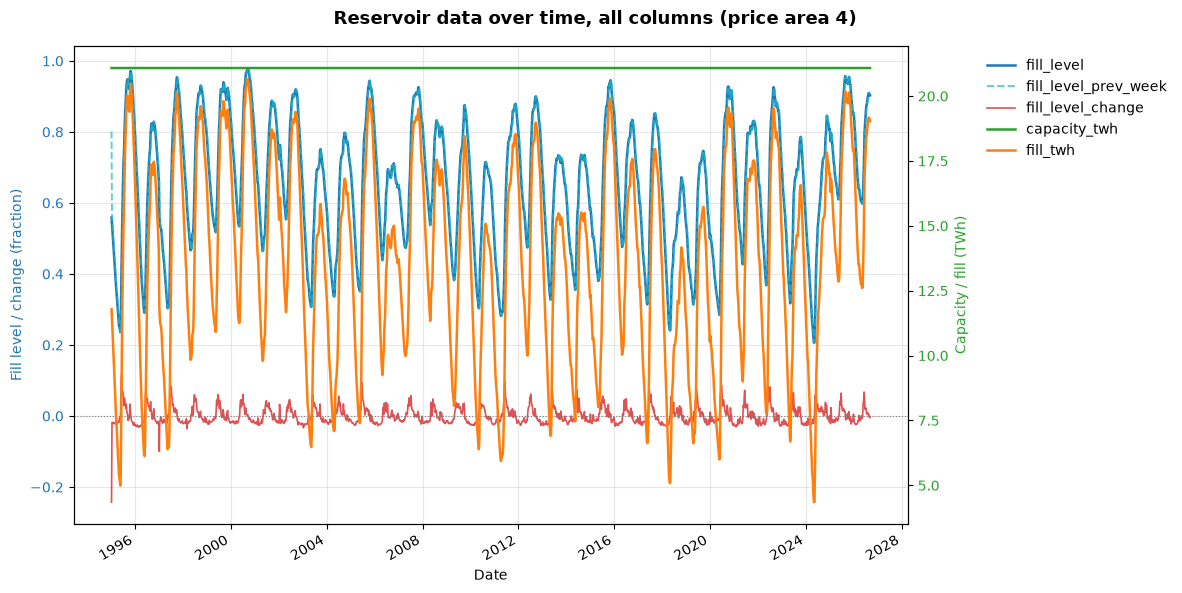

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Venstre akse: andeler / fraksjoner (naturlig skala 0-1, ingen normalisering nødvendig)
color_fill = "#1f77b4"
ax1.plot(df["date"], df["fill_level"], color=color_fill, linewidth=1.8,
          label="fill_level")
ax1.plot(df["date"], df["fill_level_prev_week"], color="#17becf", linewidth=1.4,
          linestyle="--", alpha=0.7, label="fill_level_prev_week")
ax1.plot(df["date"], df["fill_level_change"], color="#d62728", linewidth=1.2,
          alpha=0.8, label="fill_level_change")
ax1.set_xlabel("Date")
ax1.set_ylabel("Fill level / change (fraction)", color=color_fill)
ax1.tick_params(axis="y", labelcolor=color_fill)
ax1.axhline(0, color="gray", linewidth=0.8, linestyle=":")  # nullinje for change
ax1.grid(alpha=0.3)

# Høyre akse: TWh-verdier (helt annen skala, egen akse i stedet for normalisering)
ax2 = ax1.twinx()
color_twh = "#2ca02c"
ax2.plot(df["date"], df["capacity_twh"], color=color_twh, linewidth=1.8,
          label="capacity_twh")
ax2.plot(df["date"], df["fill_twh"], color="#ff7f0e", linewidth=1.8,
          label="fill_twh")
ax2.set_ylabel("Capacity / fill (TWh)", color=color_twh)
ax2.tick_params(axis="y", labelcolor=color_twh)

# Kombiner legend fra begge akser i én boks
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", bbox_to_anchor=(1.08, 1), frameon=False)

fig.suptitle(f"Reservoir data over time, all columns (price area {AREA_OF_INTEREST})",
             fontsize=13, fontweight="bold")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 7. AI usage

Generative AI (Claude, Anthropic) was used throughout this compulsory work to:
- Help structure the Streamlit multipage app and get the GitHub/Streamlit Cloud
  deployment pipeline working (including debugging a `git remote` misconfiguration
  and clarifying the difference between running a script with `python` vs.
  `streamlit run`).
- Suggest a clear, English renaming scheme for the originally Norwegian column names
  in `reservoirs.csv`.
- Draft the plotting code for both the per-column plots and the combined,
  normalised plot, including the reasoning for why normalisation was needed given
  the differing scales of the columns.
- Structure this notebook with clear markdown headings for readability and
  navigation.

All AI-suggested code was reviewed, run, and adapted (e.g. selecting the specific
price area, renaming columns to match the actual dataset) before being included.


## 8. Log (compulsory work log)
My notebook experience was that it mostly worked as i expected. I have had previous experience working in jupyter notebook, so i kinda knew how to work in it already. I think it makes it easy to simoultainously code and describe your data at the same time. I have not worked in anything else that is as easy to navigate between code and writing, and making it easy to write a report. My main issues where regarding setting up the venv. I struggled a little bit to get the venv that i created in my folder to also work in my notebook. The venv my notebook was automatically using was my anaconda venv. So i struggled to change it to the correct venv. I had to deactivate my anaconda venv, and thereafter direct into my correct venv. Other issues i encountered where for example at first i had normalised the values to show in the plot, but they were all overlapping. At first i tried to change the colors so it would be easier to see the diference, but i was not really happy with the result, I then pivoted to plotting each category on its own scale. I changed them to no longer being normalised, as we can now see all the values and it explains much more.

My experience with streamlit was good. It is a system that is easy to navigate. It is easy to navigate between pages. Once i understood how to run the streamlit app, and how to get back to the terminal after i had ran the streamlit app i felt streamlit was easy to understand. Also i got some help from claude to rename my pages as i did not know that you had to have numbers before their name to set the order. After i changed names i also was confused to why nothing changed, only after realising that i had to run the app again did i get the issue fixed. 

